# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1. Введение в PyTorch. Полносвязные нейронные сети.


### Оценивание и штрафы
Максимально допустимая оценка за работу — 10 баллов. За каждый день просрочки снимается 1 балл. Сдавать задание после жёсткого дедлайна сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.
Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как
$$
min(task_1, task_2)*0.8 + max(task_1, task_2)*0.2
$$

где task_1 и task_2 - оценки за первое и второе заданиее соответсвенно.
Также, за домашнее задание выставляется 0, если не сделано нулевое или третье задание.
### О задании

В этом задании вам предстоит предсказывать год выпуска песни (**задача регрессии**) по некоторым звуковым признакам: [данные](https://archive.ics.uci.edu/ml/datasets/yearpredictionmsd). В ячейках ниже находится код для загрузки данных. Обратите внимание, что обучающая и тестовая выборки располагаются в одном файле, поэтому НЕ меняйте ячейку, в которой производится деление данных.

In [8]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import torch.optim as optim
import random

from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
from sklearn.preprocessing import StandardScaler

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [9]:
# !wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

In [10]:
df = pd.read_csv('../datasets/data.txt.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Мы вывели кусок данных, чтобы понять, насколько они пригодны для работы без изменений. Здесь ясно, что сомнительно дальше с такими данными работать, потому что как минимум есть отрицательные значения, которые не отмасштабированы, кроме того еще сразу бросается в глаза совсем разная размерность, где-то видим реально большие числа, а где-то 0.075. Ясно, что будем скейлить.

In [11]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = 463715
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

## Задание 0. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Для самого первого бейзлайна обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями
2. Обучите StandertScaler и предобработайте ваши данные. В следующих заданиях можете использовать другой scaler или вообще отказаться от него


In [12]:
from sklearn.preprocessing import StandardScaler
import random
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [13]:
def set_random_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [14]:
set_random_seed(42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = Ridge(alpha=0.9, random_state=42)
model.fit(X_train_scaled, y_train)

Ridge(alpha=0.9, random_state=42)

In [17]:
y_pred = model.predict(X_test_scaled)
rmse_for_model = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE модели Ridge: {rmse_for_model:.4f}")

RMSE модели Ridge: 9.5102


Лучшая константа для RMSE это среднее, посчитаем значение метрики при нем

In [18]:
best_const = np.mean(y_train)
y_pred_const = np.full_like(y_test, best_const)
best_rmse_metric = np.sqrt(mean_squared_error(y_test, y_pred_const))
print(f"RMSE константного прогноза: {best_rmse_metric:.4f}")

RMSE константного прогноза: 10.8632


## Задание 1. (максимум 10 баллов)

Закрепите свои знания о том, как pytorch работает с обратным распространением ошибки, проделав следующие шаги:

1. Создайте модель линейной регрессии, которая будет состоять только из одного Linear слоя.
2. Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки pytorch. Для подсчета градиента воспользуйтесь методом backward.
3. Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
4. Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача - убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [19]:
torch.set_default_device(device)

In [20]:
train_size_max = 463_715
train_size_temp = 200_000
batch_size = 2048
features_size = X.shape[1]
X_train = X[:train_size_max, :]
y_train = y[:train_size_max]
X_test = X[train_size_max:, :]
y_test = y[train_size_max:]

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_target = StandardScaler()
y_train_scaled = scaler_target.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_target.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, device=device, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, device=device, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, device=device, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, device=device, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, generator=torch.Generator(device=device))
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [22]:
model = torch.nn.Linear(X_train_tensor.shape[1], 1)
model = model.to(device)

In [23]:
lr = 0.001
epochs = 10

train_losses, test_losses = [], []
train_rmses,  test_rmses  = [], []

  0%|          | 0/28983 [00:00<?, ?it/s]

  0%|          | 0/3227 [00:00<?, ?it/s]

Epoch: 0, loss train: 0.8475663065910339, loss test: 0.7245559096336365


  0%|          | 0/28983 [00:00<?, ?it/s]

  0%|          | 0/3227 [00:00<?, ?it/s]

...

  0%|          | 0/3227 [00:00<?, ?it/s]

Epoch: 8, loss train: 0.8394303321838379, loss test: 0.729375422000885


  0%|          | 0/28983 [00:00<?, ?it/s]

  0%|          | 0/3227 [00:00<?, ?it/s]

Epoch: 9, loss train: 0.8392085433006287, loss test: 0.7257360219955444


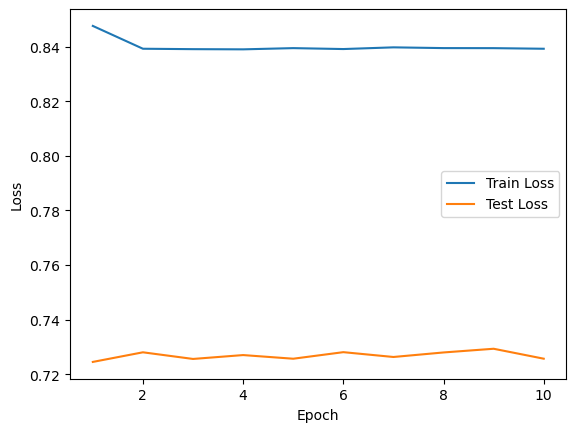

In [24]:
for epoch in range(epochs):
  val_loss_train = []
  model.train()
  for X_batch, y_batch in tqdm(train_dataloader):
    y_pred = model(X_batch)
    loss = torch.sqrt(torch.mean((y_pred - y_batch) ** 2))
    val_loss_train.append(loss.detach().cpu().numpy())
    loss.backward()

    with torch.no_grad():
      for param in model.parameters():
        param.data -= lr * param.grad
    model.zero_grad()

  val_loss_test = []
  model.eval()
  with torch.no_grad():
    for X_batch, y_batch in tqdm(test_dataloader):
      y_pred = model(X_batch)
      loss = torch.sqrt(torch.mean((y_pred - y_batch) ** 2))
      val_loss_test.append(loss.detach().cpu().numpy())

  train_losses.append(np.mean(val_loss_train))
  test_losses.append(np.mean(val_loss_test))
  print(
        f"Epoch: {epoch}, loss train: {np.mean(val_loss_train)}, loss test: {np.mean(val_loss_test)}"
    )

plt.plot(range(1, 11), train_losses, label="Train Loss")
plt.plot(range(1, 11), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Задание 2. (максимум 10 баллов)

Реализуйте обучение и тестирование нейронной сети для предоставленного вам набора данных. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 9.00 $ &mdash; 4 балла
- $\text{RMSE} \le 8.90 $ &mdash; 6 баллов
- $\text{RMSE} \le 8.80 $ &mdash; 8 баллов
- $\text{RMSE} \le 8.75 $ &mdash; 10 баллов

Есть несколько правил, которых вам нужно придерживаться:

- Весь пайплайн обучения должен быть написан на PyTorch. При этом вы можете пользоваться другими библиотеками (`numpy`, `sklearn` и пр.), но только для обработки данных. То есть как угодно трансформировать данные и считать метрики с помощью этих библиотек можно, а импортировать модели из `sklearn` и выбивать с их помощью требуемое качество &mdash; нельзя. Также нельзя пользоваться библиотеками, для которых сам PyTorch является зависимостью.

- Мы никак не ограничиваем ваш выбор архитектуры модели, но скорее всего вам будет достаточно полносвязной нейронной сети.

- Для обучения запрещается использовать какие-либо иные данные, кроме обучающей выборки.

- Ансамблирование моделей запрещено.

### Полезные советы:

- Очень вряд ли, что у вас с первого раза получится выбить качество на 10 баллов, поэтому пробуйте разные архитектуры, оптимизаторы и значения гиперпараметров. В идеале при запуске каждого нового эксперимента вы должны менять что-то одно, чтобы точно знать, как этот фактор влияет на качество.

- Не забудьте, что для улучшения качества модели вам поможет **нормировка таргета**.

- Тот факт, что мы занимаемся глубинным обучением, не означает, что стоит забывать про приемы, использующиеся в классическом машинном обучении. Так что обязательно проводите исследовательский анализ данных, отрисовывайте нужные графики и не забывайте про масштабирование и подбор гиперпараметров.

- Вы наверняка столкнетесь с тем, что ваша нейронная сеть будет сильно переобучаться. Для нейросетей существуют специальные методы регуляризации, например, dropout ([статья](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) и weight decay ([блогпост](https://towardsdatascience.com/weight-decay-l2-regularization-90a9e17713cd)). Они, разумеется, реализованы в PyTorch. Попробуйте поэкспериментировать с ними.

- Если вы чего-то не знаете, не гнушайтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению в целом и по PyTorch в частности. Но не забывайте, что за скатанный код без ссылки на источник придется ответить по всей строгости!

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так!

- Пользуйтесь утилитами, которые вам предоставляет PyTorch (например, Dataset и Dataloader). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

**ОБЯЗАТЕЛЬНО** рисуйте графики зависимости лосса/метрики на обучающей и тестовой выборках в зависимости от времени обучения. Если обучение занимает относительно небольшое число эпох, то лучше рисовать зависимость от номера шага обучения, если же эпох больше, то рисуйте зависимость по эпохам. Если проверяющий не увидит такого графика для вашей лучшей модели, то он в праве снизить баллы за задание.

**ВАЖНО!** Ваше решение должно быть воспроизводимым. Если это не так, то проверяющий имеет право снизить баллы за задание. Чтобы зафиксировать random seed, воспользуйтесь функцией из предыдущего задания.



Вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. Лучше всего, если вы проверите ваши предсказания ассертом: так вы убережете себя от разных косяков, например, что вектор предсказаний состоит из всего одного числа. В любом случае, внимательно следите за тем, для каких тензоров вы считаете метрику RMSE. При случайном или намеренном введении в заблуждение проверяющие очень сильно разозлятся.

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_target = StandardScaler()
y_train_scaled = scaler_target.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_target.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, device=device, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, device=device, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, device=device, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, device=device, dtype=torch.float32).view(-1, 1)

y_train_orig = y_train.reshape(-1, 1)
y_test_orig = y_test.reshape(-1, 1)

In [26]:
class YearDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.x = X
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, key):
        return {
            'sample': self.x[key],
            'target': self.y[key]
        }

In [27]:
class YearModel(nn.Module):
    def __init__(self, input_dim):
        super(YearModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.out = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        return self.out(x)

In [28]:
batch_size = 512

train_set = YearDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))

test_set = YearDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

model = YearModel(input_dim=features_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [29]:
model

YearModel(
  (fc1): Linear(in_features=90, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)

In [30]:
def train(model, optimizer, criterion, train_loader, test_loader):
    """
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        test_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    train_losses, test_losses = [], []
    train_rmses, test_rmses = [], []

    epochs = 30
    progress_bar = tqdm(range(1, epochs+1), desc='Training')
    for epoch in progress_bar:
        model.train()
        epoch_train_loss = 0.0
        for batch in train_loader:
            inputs = batch['sample']
            targets = batch['target'].view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * inputs.size(0)

        avg_train_loss = epoch_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)



        model.eval()
        with torch.no_grad():
          total_sq_error = 0.0
          total_samples = 0
          for batch in test_loader:
              inputs = batch['sample']
              targets = batch['target'].view(-1, 1)
              outputs = model(inputs)

              outputs_np = outputs.cpu().numpy()
              targets_np = targets.cpu().numpy()

              outputs_np_orig = scaler_target.inverse_transform(outputs_np)
              targets_np_orig = scaler_target.inverse_transform(targets_np)

              sq_error = np.sum((targets_np_orig - outputs_np_orig) ** 2)
              total_sq_error += sq_error
              total_samples += len(targets_np_orig)

        test_rmse_orig = np.sqrt(total_sq_error / total_samples)

        progress_bar.set_postfix({
            'Train Loss': f'{avg_train_loss:.4f}',
            'Test RMSE': f'{test_rmse_orig:.4f}'
        })
        print(f"\rЭпоха {epoch}/{epochs} | Loss: {avg_train_loss:.4f} | Test RMSE: {test_rmse_orig:.4f}", end='')
        print()

    return train_losses, test_losses, train_rmses, test_rmses


def test(model, criterion, test_loader):
    """
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = []
    with torch.no_grad():
      for X_batch, y_batch in tqdm(test_dataloader):
        y_pred = model(X_batch)
        predicts.extend(y_batch.cpu().numpy())

    predicts = torch.ones(len(test_loader.dataset))
    return predicts


In [31]:
train(model, optimizer, criterion, train_loader, test_loader)

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Эпоха 1/30 | Loss: 0.6945 | Test RMSE: 8.9022
Эпоха 2/30 | Loss: 0.6647 | Test RMSE: 8.8375
Эпоха 3/30 | Loss: 0.6568 | Test RMSE: 8.7980
Эпоха 4/30 | Loss: 0.6516 | Test RMSE: 8.7883
Эпоха 5/30 | Loss: 0.6478 | Test RMSE: 8.7847
Эпоха 6/30 | Loss: 0.6452 | Test RMSE: 8.7776
Эпоха 7/30 | Loss: 0.6429 | Test RMSE: 8.7579
Эпоха 8/30 | Loss: 0.6408 | Test RMSE: 8.7659
Эпоха 9/30 | Loss: 0.6389 | Test RMSE: 8.7551
Эпоха 10/30 | Loss: 0.6373 | Test RMSE: 8.7758
Эпоха 11/30 | Loss: 0.6358 | Test RMSE: 8.7416
Эпоха 12/30 | Loss: 0.6349 | Test RMSE: 8.7445
Эпоха 13/30 | Loss: 0.6336 | Test RMSE: 8.7407
Эпоха 14/30 | Loss: 0.6315 | Test RMSE: 8.7627
Эпоха 15/30 | Loss: 0.6317 | Test RMSE: 8.7630
Эпоха 16/30 | Loss: 0.6296 | Test RMSE: 8.7437
Эпоха 17/30 | Loss: 0.6303 | Test RMSE: 8.7534
Эпоха 18/30 | Loss: 0.6285 | Test RMSE: 8.7324
Эпоха 19/30 | Loss: 0.6276 | Test RMSE: 8.7353
Эпоха 20/30 | Loss: 0.6275 | Test RMSE: 8.7522
Эпоха 21/30 | Loss: 0.6267 | Test RMSE: 8.7448
Эпоха 22/30 | Loss: 0.

([0.6944679125697271,
  0.6647228867747783,
  0.6567902730324464,
  0.6515896674385983,
  0.6477667561076682,
  0.6451609563462726,
  0.6428519951690901,
  0.6408152448663522,
  0.6388820317341083,
  0.637347934679568,
  0.6358077027663686,
  0.6349495848489507,
  0.6335993891391236,
  0.6315187974682474,
  0.6317310941010714,
  0.6296148799979588,
  0.6302724562244971,
  0.6284949539855391,
  0.6276210968114948,
  0.6275296646305232,
  0.6266828163620052,
  0.626086498550293,
  0.6255503680137299,
  0.6259431627649619,
  0.6250272824795537,
  0.6241209657251126,
  0.6226722618730516,
  0.6229425028505874,
  0.622957134724342,
  0.6211485050618247],
 [],
 [],
 [])

In [32]:
model.eval()
pred = model(X_test_tensor)
pred = scaler_target.inverse_transform(pred.cpu().detach().numpy())
pred_t = torch.tensor(pred, device=device, dtype=torch.float32)

In [33]:
rmse_test_loss = np.sqrt(np.mean(((y_test_orig - pred)**2)))
rmse_test_loss

8.743973126568639

In [34]:
assert test(model, criterion, test_loader).shape[0] == y_test.shape[0]

  0%|          | 0/3227 [00:00<?, ?it/s]

In [35]:
test(model, criterion, test_loader)

  0%|          | 0/3227 [00:00<?, ?it/s]

tensor([1., 1., 1.,  ..., 1., 1., 1.])